# 8U CubeSat Power Generation

Demonstration of the **missiontools** solar power tools.

**Scenario**
- 8U CubeSat (10 × 20 × 40 cm, 1×2×4U configuration)
- 500 km sun-synchronous orbit, nadir-pointed
- Solar cells on all faces except nadir, 80% fill factor, 30% efficiency
- Two cases: LTAN 12:00 (noon) and LTAN 06:00 (dawn-dusk)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from missiontools import Spacecraft, NormalVectorSolarConfig
from missiontools.attitude import FixedAttitudeLaw

## 1. CubeSat geometry

Body frame convention (nadir pointing): body-z = nadir, body-x = along-track.
The 40 cm long axis is along body-z (nadir), so the nadir face (+z) is 10 × 20 cm.

In [2]:
FILL_FACTOR = 0.80
EFFICIENCY  = 0.30

# Panel normals (body frame) and gross areas (m²)
faces = {
    'Zenith (+Z anti-nadir)': ([0, 0, -1], 0.10 * 0.20),
    '+X side':                ([1, 0,  0], 0.20 * 0.40),
    '-X side':               ([-1, 0,  0], 0.20 * 0.40),
    '+Y side':                ([0, 1,  0], 0.10 * 0.40),
    '-Y side':                ([0, -1, 0], 0.10 * 0.40),
}

normals = np.array([v[0] for v in faces.values()], dtype=float)
areas   = np.array([v[1] * FILL_FACTOR for v in faces.values()])

print(f"{'Face':<30} {'Normal':>14} {'Cell area (cm²)':>16}")
print('-' * 62)
for name, (n, a_gross) in faces.items():
    print(f"{name:<30} {str(n):>14} {a_gross * FILL_FACTOR * 1e4:>13.1f}")
print(f"{'Total':<30} {'':>14} {areas.sum() * 1e4:>13.1f}")

Face                                   Normal  Cell area (cm²)
--------------------------------------------------------------
Zenith (+Z anti-nadir)             [0, 0, -1]         160.0
+X side                             [1, 0, 0]         640.0
-X side                            [-1, 0, 0]         640.0
+Y side                             [0, 1, 0]         320.0
-Y side                            [0, -1, 0]         320.0
Total                                                2080.0


## 2. LTAN 12:00 (noon orbit)

In [ ]:
EPOCH = np.datetime64('2025-03-20T12:00:00', 'us')  # spring equinox

sc_noon = Spacecraft.sunsync(
    altitude_km=500.0,
    node_solar_time='12:00',
    epoch=EPOCH,
)
sc_noon.attitude_law = FixedAttitudeLaw.nadir(0.0) # no rotation around local zenith

cfg_noon = NormalVectorSolarConfig(normals, areas, efficiency=EFFICIENCY)
sc_noon.add_solar_config(cfg_noon)

print(f"Altitude        : 500 km")
print(f"Inclination     : {np.degrees(sc_noon.i):.2f}°")
print(f"LTAN            : 12:00")
print(f"Propagator      : {sc_noon.propagator_type}")

In [4]:
# Orbital period
mu = sc_noon.central_body_mu
period_s = 2 * np.pi * np.sqrt(sc_noon.a**3 / mu)
period   = np.timedelta64(int(period_s * 1e6), 'us')

# Power generation over one orbit
result_noon = cfg_noon.generation(EPOCH, EPOCH + period, np.timedelta64(10, 's'))
oap_noon    = cfg_noon.oap()

print(f"Orbital period  : {period_s / 60:.1f} min")
print(f"Orbit avg power : {oap_noon:.2f} W")

Orbital period  : 94.6 min
Orbit avg power : 13.56 W


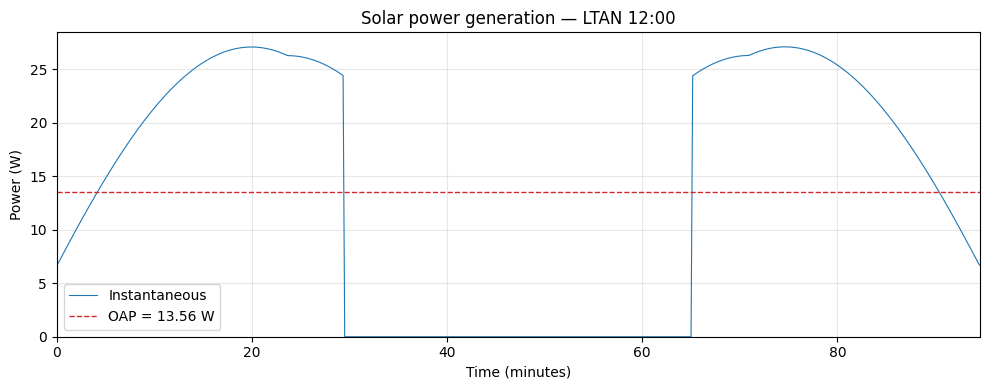

In [5]:
elapsed_noon = (result_noon['t'] - result_noon['t'][0]) / np.timedelta64(1, 'm')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(elapsed_noon, result_noon['power'], linewidth=0.8, label='Instantaneous')
ax.axhline(oap_noon, color='tab:red', linestyle='--', linewidth=1, label=f'OAP = {oap_noon:.2f} W')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Power (W)')
ax.set_title('Solar power generation \u2014 LTAN 12:00')
ax.legend()
ax.set_xlim(0, elapsed_noon[-1])
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. LTAN 06:00 (dawn-dusk orbit)

In [ ]:
sc_dd = Spacecraft.sunsync(
    altitude_km=500.0,
    node_solar_time='06:00',
    epoch=EPOCH,
)
sc_dd.attitude_law = FixedAttitudeLaw.nadir(0.5*np.pi) # rotate 90 degrees about local zenith for peak generation

cfg_dd = NormalVectorSolarConfig(normals, areas, efficiency=EFFICIENCY)
sc_dd.add_solar_config(cfg_dd)

result_dd = cfg_dd.generation(EPOCH, EPOCH + period, np.timedelta64(10, 's'))
oap_dd    = cfg_dd.oap()

print(f"LTAN            : 06:00")
print(f"Orbit avg power : {oap_dd:.2f} W")

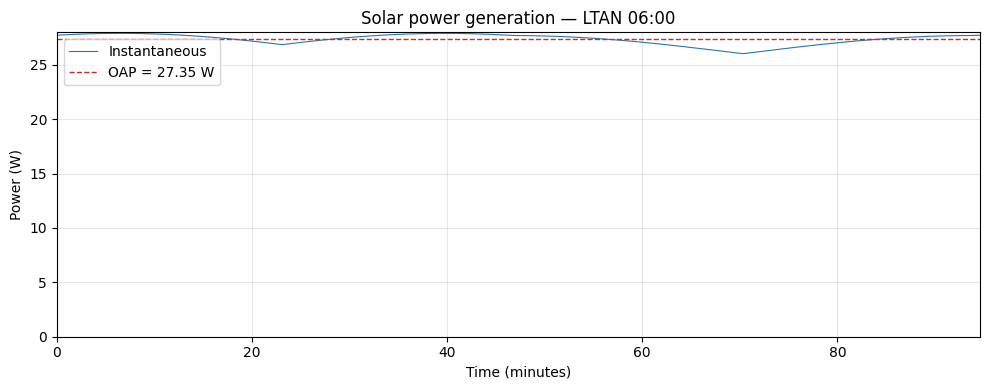

In [7]:
elapsed_dd = (result_dd['t'] - result_dd['t'][0]) / np.timedelta64(1, 'm')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(elapsed_dd, result_dd['power'], linewidth=0.8, label='Instantaneous')
ax.axhline(oap_dd, color='tab:red', linestyle='--', linewidth=1, label=f'OAP = {oap_dd:.2f} W')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Power (W)')
ax.set_title('Solar power generation \u2014 LTAN 06:00')
ax.legend()
ax.set_xlim(0, elapsed_dd[-1])
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Comparison

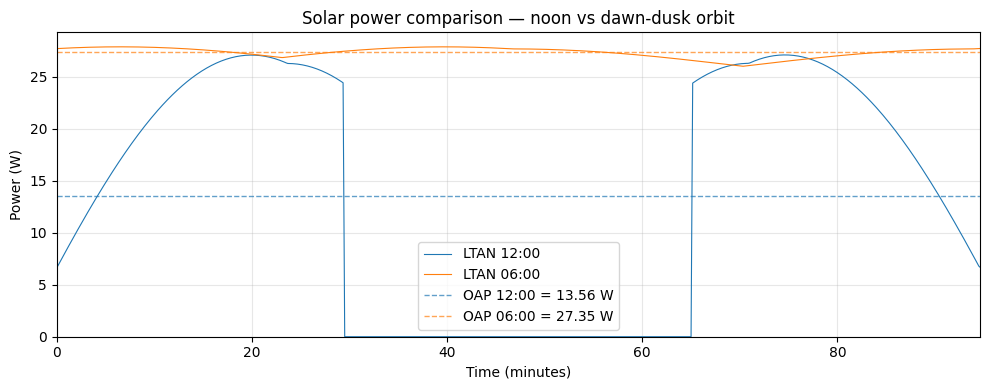

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(elapsed_noon, result_noon['power'], linewidth=0.8, label='LTAN 12:00', color='tab:blue')
ax.plot(elapsed_dd,   result_dd['power'],   linewidth=0.8, label='LTAN 06:00', color='tab:orange')
ax.axhline(oap_noon, color='tab:blue',   linestyle='--', linewidth=1, alpha=0.7, label=f'OAP 12:00 = {oap_noon:.2f} W')
ax.axhline(oap_dd,   color='tab:orange', linestyle='--', linewidth=1, alpha=0.7, label=f'OAP 06:00 = {oap_dd:.2f} W')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Power (W)')
ax.set_title('Solar power comparison \u2014 noon vs dawn-dusk orbit')
ax.legend()
ax.set_xlim(0, max(elapsed_noon[-1], elapsed_dd[-1]))
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
print('=' * 45)
print('Power summary \u2014 8U CubeSat, 500 km SSO')
print('=' * 45)
print(f"{'':20} {'LTAN 12:00':>12} {'LTAN 06:00':>12}")
print('-' * 45)
print(f"{'OAP (W)':20} {oap_noon:>12.2f} {oap_dd:>12.2f}")
print(f"{'Peak power (W)':20} {result_noon['power'].max():>12.2f} {result_dd['power'].max():>12.2f}")
eclipse_noon = (result_noon['power'] == 0).sum() / len(result_noon['power']) * 100
eclipse_dd   = (result_dd['power'] == 0).sum()   / len(result_dd['power'])   * 100
print(f"{'Eclipse fraction':20} {eclipse_noon:>11.1f}% {eclipse_dd:>11.1f}%")

Power summary — 8U CubeSat, 500 km SSO
                       LTAN 12:00   LTAN 06:00
---------------------------------------------
OAP (W)                     13.56        27.35
Peak power (W)              27.11        27.89
Eclipse fraction            37.6%         0.0%
